# Eigenfraud — Single-image Inference

Load two images (one real, one fake), run both checkpoints, and see the predictions.

In [23]:
import sys
sys.path.insert(0, '..')  # so src/ is importable from notebooks/

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from src.transforms import to_grayscale_array, log_power_spectrum_2d, azimuthal_average_fast
from src.models import build_model

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

device: cpu


## 1. Set your image paths here

In [24]:
IMAGE_A = '../1.png'   # <-- change me
IMAGE_B = '../2.png'   # <-- change me

CHECKPOINT_1D = '../results/best_1d.pt'
CHECKPOINT_2D = '../results/best_2d.pt'

## 2. Helper: preprocess one image → both representations

In [25]:
def preprocess(path: str, size: int = 224):
    img = Image.open(path)
    gray = to_grayscale_array(img, size=size)          # (224, 224)
    spec2d = log_power_spectrum_2d(gray)               # (224, 224)
    prof1d = azimuthal_average_fast(spec2d)            # (112,)

    t2d = torch.from_numpy(spec2d).unsqueeze(0).unsqueeze(0)  # (1, 1, 224, 224)
    t1d = torch.from_numpy(prof1d).unsqueeze(0)               # (1, 112)
    return img, gray, spec2d, prof1d, t1d, t2d

## 3. Helper: load checkpoint and run inference

In [26]:
def predict(checkpoint_path: str, t1d: torch.Tensor, t2d: torch.Tensor, device: str = DEVICE):
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model_type = ckpt["model_type"]
    model = build_model(model_type).to(device)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    inp = (t1d if model_type == "1d" else t2d).to(device)
    with torch.no_grad():
        logits = model(inp)                         # (1, 2)
        probs = torch.softmax(logits, dim=-1)[0]    # (2,)

    p_real = probs[0].item()
    p_fake = probs[1].item()
    label = "FAKE" if p_fake > 0.5 else "REAL"
    val_auc = ckpt.get("val_auc", float("nan"))

    return {
        "model_type": model_type,
        "val_auc": val_auc,
        "p_real": p_real,
        "p_fake": p_fake,
        "prediction": label,
    }

## 4. Run on both images

In [27]:
images = {
    '1.png': IMAGE_A,
    '2.png': IMAGE_B,
}

results = {}
preprocessed = {}

for name, path in images.items():
    img, gray, spec2d, prof1d, t1d, t2d = preprocess(path)
    preprocessed[name] = (img, gray, spec2d, prof1d)

    r1d = predict(CHECKPOINT_1D, t1d, t2d)
    r2d = predict(CHECKPOINT_2D, t1d, t2d)
    results[name] = {'1D CNN': r1d, '2D CNN': r2d}

    avg_fake = (r1d['p_fake'] + r2d['p_fake']) / 2
    verdict = 'AI GENERATED' if avg_fake > 0.5 else 'REAL'
    confidence = max(avg_fake, 1 - avg_fake) * 100

    sep = '=' * 40
    print(sep)
    print('  ' + name)
    print('  Verdict:    ' + verdict)
    print('  Confidence: ' + f'{confidence:.1f}%')
    print('  1D model P(fake): ' + f"{r1d['p_fake']:.2f}" + '  |  2D model P(fake): ' + f"{r2d['p_fake']:.2f}")
    print(sep)


  1.png
  Verdict:    AI GENERATED
  Confidence: 50.0%
  1D model P(fake): 0.00  |  2D model P(fake): 1.00
  2.png
  Verdict:    AI GENERATED
  Confidence: 50.0%
  1D model P(fake): 0.00  |  2D model P(fake): 1.00


## 5. Visualise: original | spectrum | radial profile

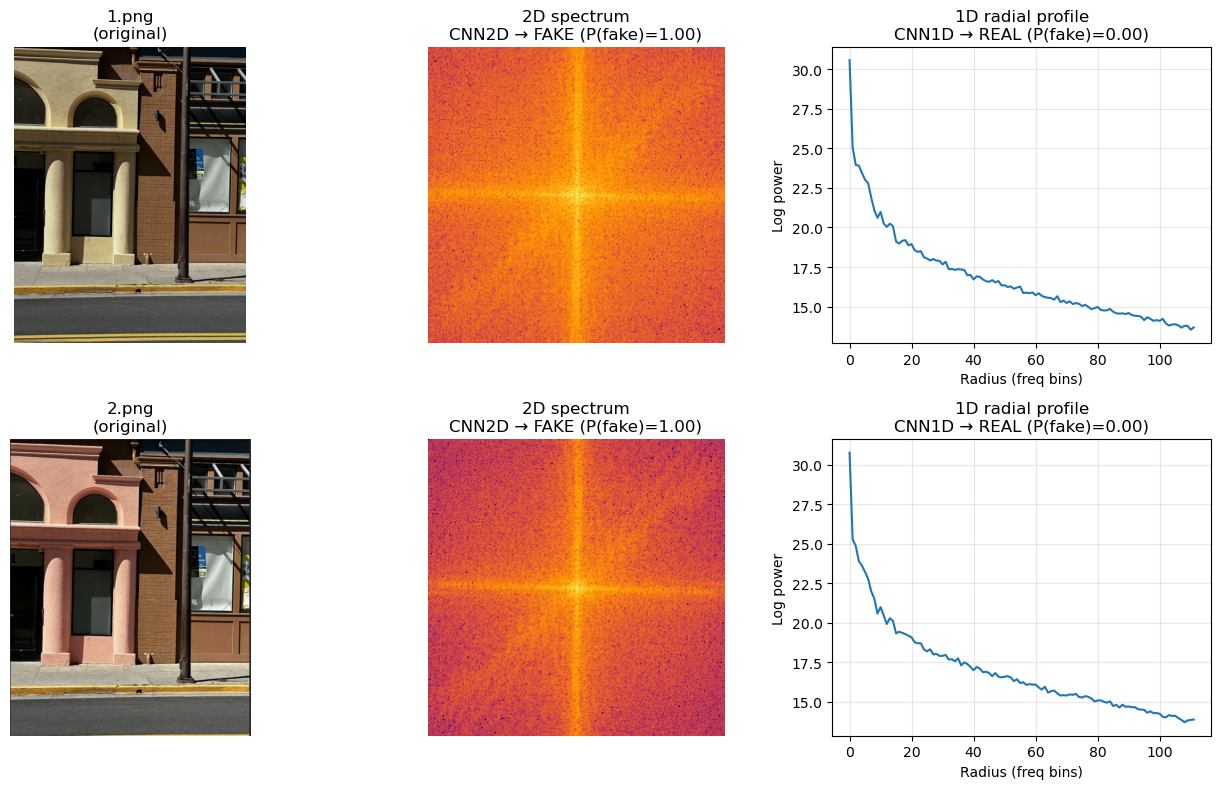

Saved → results/inference_preview.png


In [28]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for row, (name, path) in enumerate(images.items()):
    img, gray, spec2d, prof1d = preprocessed[name]
    r1d = results[name]['1D CNN']
    r2d = results[name]['2D CNN']

    # Original image
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"{name}\n(original)")
    axes[row, 0].axis('off')

    # 2D log-power spectrum
    axes[row, 1].imshow(np.log1p(spec2d), cmap='inferno')
    axes[row, 1].set_title(
        f"2D spectrum\n"
        f"CNN2D → {r2d['prediction']} "
        f"(P(fake)={r2d['p_fake']:.2f})"
    )
    axes[row, 1].axis('off')

    # 1D radial profile
    axes[row, 2].plot(prof1d, linewidth=1.5)
    axes[row, 2].set_title(
        f"1D radial profile\n"
        f"CNN1D → {r1d['prediction']} "
        f"(P(fake)={r1d['p_fake']:.2f})"
    )
    axes[row, 2].set_xlabel('Radius (freq bins)')
    axes[row, 2].set_ylabel('Log power')
    axes[row, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/inference_preview.png', dpi=150)
plt.show()
print('Saved → results/inference_preview.png')